# Step 1. 데이터 수집 (10년, 2016-01 ~ 2025-12)

PJ12 v3 프로젝트의 첫 단계로, **30개 투자 자산 + 7개 외부 지표 + 10개 대안데이터**를 수집합니다.

---

## 데이터 구성 요약

| 구분 | 개수 | 소스 | 역할 |
|------|------|------|------|
| 인덱스 ETF | 5 | yfinance | 자산군 대표 (미국대형/기술/소형/선진/신흥) |
| 채권 ETF | 4 | yfinance | 듀레이션 스펙트럼 (장기/종합/단기/물가연동) |
| 대안 ETF | 2 | yfinance | 금 + 원자재 바스켓 |
| 섹터 ETF | 11 | yfinance | GICS 11개 전 섹터 |
| 개별 종목 | 8 | yfinance | 섹터별 시총 1위 (초기 고정, 이후 Step3에서 재구성) |
| 외부 지표 | 7 | yfinance | 원유/금/은/BTC/ETH/VIX/달러 |
| 대안 원시 | 5 | yfinance | VIX9D/VIX3M/VIX6M/SKEW/구리 |
| 대안 FRED | 5 | FRED | HY스프레드/수익률곡선/실업수당/WEI/Sahm |
| 기존 FRED | 3 | FRED | 10Y금리/CPI/실업률 |

In [ ]:
# ============================================================
# 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import yfinance as yf
import os, warnings, time
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

# ── 경로 설정 ──
V3_DIR   = os.getcwd()  # PJ12_v3_Final/
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ── 분석 기간 (10년) ──
# 2016-01 시작 근거: ETH-USD(2015-08 시작)의 5개월 이력 확보
START = '2016-01-01'
END   = '2025-12-31'

print(f'분석 기간: {START} ~ {END} (10년)')
print(f'저장 경로: {DATA_DIR}')

분석 기간: 2016-01-01 ~ 2025-12-31 (10년)
저장 경로: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/data


In [21]:
import os
from dotenv import load_dotenv
from fredapi import Fred

status = load_dotenv('.env')  # .env 파일 로드
print(f"파일 로드 성공 여부: {status}") # False가 뜨면 파일 경로 문제!
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])

파일 로드 성공 여부: True


---
## 1-1. 투자 자산 정의 (30개)

### 인덱스 ETF (5개) — 자산군 대표
| 티커 | 자산군 | 역할 |
|------|--------|------|
| SPY | 미국 대형주 | S&P 500 대표, Level 1 주식 대표 |
| QQQ | 미국 기술주 | NASDAQ-100, 성장주 노출 |
| IWM | 미국 소형주 | Russell 2000, 내수 경기 민감 |
| EFA | 선진국 주식 | MSCI EAFE (유럽/일본), 지역 분산 |
| EEM | 신흥국 주식 | MSCI EM, 달러/원자재 민감 |

### 채권 ETF (4개) — 듀레이션 스펙트럼
| 티커 | 설명 | 역할 |
|------|------|------|
| TLT | 미국 20Y+ 장기 국채 | 금리 하락 시 수혜, 위기 방어 |
| AGG | 미국 종합 채권 | 안정적 인컴, Level 1 채권 대표 |
| SHY | 미국 1-3Y 단기 국채 | 금리 상승기 방어, 변동성 최저 |
| TIP | 미국 TIPS 물가연동채 | 인플레이션 직접 헤지 |

### 대안 ETF (2개)
| 티커 | 설명 | 역할 |
|------|------|------|
| GLD | 금 ETF | 안전자산, Level 1 대안 대표 |
| DBC | 원자재 바스켓 ETF | 인플레이션 헤지, XLB와 다른 자산 클래스(선물 vs 주식) |

### 섹터 ETF (11개) — GICS 전 섹터
| 티커 | 섹터 | 비고 |
|------|------|------|
| XLK | Technology | |
| XLF | Financials | |
| XLE | Energy | |
| XLV | Healthcare | |
| VOX | Communication Services | XLC(2018) 대신 VOX(2004) 사용 |
| XLY | Consumer Discretionary | |
| XLP | Consumer Staples | |
| XLI | Industrials | |
| XLU | Utilities | |
| XLRE | Real Estate | VNQ 대신 XLRE 사용 (섹터 ETF로 통일) |
| XLB | Materials | |

### 개별 종목 (8개) — 초기 선정 (2016-01 기준 섹터별 시총 1위)
| 티커 | 섹터 | 비고 |
|------|------|------|
| AAPL | IT | 전 기간 시총 최상위 |
| MSFT | IT(2위) → 별도 | 전 기간 안정적 |
| AMZN | Consumer Disc. | |
| GOOGL | Communication | |
| JPM | Financials | |
| JNJ | Healthcare | 2023 Kenvue 분사 주의 |
| PG | Consumer Staples | |
| XOM | Energy | 2016년 시총 상위, 에너지 대표 |

In [22]:
# ============================================================
# 티커 정의
# ============================================================

# ── 투자 자산 (30개) ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
            'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

# 전체 투자 자산
ALL_PORTFOLIO = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS
print(f'투자 자산: {len(ALL_PORTFOLIO)}개')
print(f'  인덱스 ETF: {INDEX_ETF}')
print(f'  채권 ETF:   {BOND_ETF}')
print(f'  대안 ETF:   {ALT_ETF}')
print(f'  섹터 ETF:   {SECTOR_ETF}')
print(f'  개별 종목:  {STOCKS}')

# ── 외부 지표 (7개, 투자하지 않고 관찰만) ──
EXTERNAL = {
    'CL=F':    'WTI 원유 선물',
    'GC=F':    '금 선물 (COMEX)',
    'SI=F':    '은 선물 (COMEX)',
    'BTC-USD': '비트코인',
    'ETH-USD': '이더리움 (2016-01부터)',
    '^VIX':    'VIX (공포 지수)',
    'DX-Y.NYB':'DXY (달러 인덱스)',
}
print(f'\n외부 지표: {len(EXTERNAL)}개 — {list(EXTERNAL.keys())}')

# ── 대안데이터 yfinance (5개) ──
ALT_YF = {
    '^VIX9D': 'VIX 9-Day (초단기 내재 변동성)',
    '^VIX3M': 'VIX 3-Month (중기 내재 변동성)',
    '^VIX6M': 'VIX 6-Month (장기 내재 변동성)',
    '^SKEW':  'CBOE SKEW Index (꼬리 위험)',
    'HG=F':   'Copper Futures (구리 선물)',
}
print(f'대안 yfinance: {len(ALT_YF)}개 — {list(ALT_YF.keys())}')

# ── 대안데이터 FRED (5개) ──
ALT_FRED = {
    'BAMLH0A0HYM2': 'HY OAS (하이일드 신용스프레드)',
    'T10Y2Y':        '10Y-2Y 수익률 곡선 스프레드',
    'ICSA':          '신규 실업수당 청구 (주간)',
    'WEI':           'Weekly Economic Index (주간)',
    'SAHMREALTIME':  'Sahm 경기침체 지표 (월간)',
}

# ── 기존 FRED 매크로 (3개) ──
MACRO_FRED = {
    'DGS10':    '미국 10Y 국채 수익률',
    'CPIAUCSL': '소비자물가지수 (CPI)',
    'UNRATE':   '실업률',
}
print(f'FRED 대안: {len(ALT_FRED)}개, 기존 매크로: {len(MACRO_FRED)}개')
print(f'\n총 수집 대상: {len(ALL_PORTFOLIO) + len(EXTERNAL) + len(ALT_YF) + len(ALT_FRED) + len(MACRO_FRED)}개')

투자 자산: 30개
  인덱스 ETF: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
  채권 ETF:   ['TLT', 'AGG', 'SHY', 'TIP']
  대안 ETF:   ['GLD', 'DBC']
  섹터 ETF:   ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
  개별 종목:  ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

외부 지표: 7개 — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', '^VIX', 'DX-Y.NYB']
대안 yfinance: 5개 — ['^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']
FRED 대안: 5개, 기존 매크로: 3개

총 수집 대상: 50개


---
## 1-2. yfinance 시세 수집

투자 자산 30개 + 외부 지표 7개 + 대안 yfinance 5개 = **42개 티커**를 수집합니다.  
각 티커를 개별적으로 수집하여, 일부 실패 시에도 나머지가 유지되도록 합니다.

In [23]:
# ============================================================
# yfinance 일괄 수집 (42개 티커)
# ============================================================

all_yf_tickers = ALL_PORTFOLIO + list(EXTERNAL.keys()) + list(ALT_YF.keys())
print(f'yfinance 수집 대상: {len(all_yf_tickers)}개 티커')

# 개별 수집 (안정성 우선)
yf_data = {}
failed = []

for i, ticker in enumerate(all_yf_tickers, 1):
    try:
        df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
        if df.empty:
            print(f'  [{i:2d}/{len(all_yf_tickers)}] [WARN] {ticker:12s} — 데이터 없음')
            failed.append(ticker)
            continue
        # Close 가격 추출 (MultiIndex 대응)
        if isinstance(df.columns, pd.MultiIndex):
            series = df[('Close', ticker)].dropna()
        else:
            series = df['Close'].dropna()
        yf_data[ticker] = series
        if i % 10 == 0 or i == len(all_yf_tickers):
            print(f'  [{i:2d}/{len(all_yf_tickers)}] {ticker:12s} — {len(series):,}일 수집 완료')
    except Exception as e:
        print(f'  [{i:2d}/{len(all_yf_tickers)}] [ERR] {ticker:12s} — {e}')
        failed.append(ticker)

print(f'\n수집 완료: {len(yf_data)}개 성공, {len(failed)}개 실패')
if failed:
    print(f'실패 티커: {failed}')

yfinance 수집 대상: 42개 티커
  [10/42] GLD          — 2,513일 수집 완료
  [20/42] XLU          — 2,513일 수집 완료
  [30/42] XOM          — 2,513일 수집 완료
  [40/42] ^VIX6M       — 2,513일 수집 완료
  [42/42] HG=F         — 2,513일 수집 완료

수집 완료: 42개 성공, 0개 실패


In [24]:
# ============================================================
# DataFrame 병합 + NYSE 영업일 정렬
# ============================================================

# 전체 DataFrame 구성
df_all_prices = pd.DataFrame(yf_data)
df_all_prices.index = pd.to_datetime(df_all_prices.index)
df_all_prices = df_all_prices.sort_index()

# NYSE 영업일 캘린더 정렬
nyse_dates = pd.bdate_range(start=START, end=END, freq='B')
df_all_prices = df_all_prices.reindex(nyse_dates)
df_all_prices = df_all_prices.ffill().bfill()
df_all_prices.index.name = 'Date'

print(f'전체 시세 DataFrame: {df_all_prices.shape}')
print(f'NYSE 영업일: {len(nyse_dates):,}일')
print(f'기간: {df_all_prices.index[0].date()} ~ {df_all_prices.index[-1].date()}')
print(f'\n결측률:')
missing = df_all_prices.isnull().sum()
if missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(missing[missing > 0])

전체 시세 DataFrame: (2609, 42)
NYSE 영업일: 2,609일
기간: 2016-01-01 ~ 2025-12-31

결측률:
  전 컬럼 결측 0개


In [25]:
# ============================================================
# 투자 자산과 외부/대안 지표 분리 저장
# ============================================================

# 투자 자산 (30개) — 실제 매매 대상
port_cols = [c for c in ALL_PORTFOLIO if c in df_all_prices.columns]
df_portfolio = df_all_prices[port_cols]

# 외부 지표 + 대안 yfinance (12개) — 관찰만
ext_alt_cols = [c for c in list(EXTERNAL.keys()) + list(ALT_YF.keys()) if c in df_all_prices.columns]
df_ext_alt = df_all_prices[ext_alt_cols]

print(f'투자 자산: {df_portfolio.shape} — {list(df_portfolio.columns)}')
print(f'외부+대안: {df_ext_alt.shape} — {list(df_ext_alt.columns)}')

투자 자산: (2609, 30) — ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
외부+대안: (2609, 12) — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', '^VIX', 'DX-Y.NYB', '^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']


---
## 1-3. FRED 데이터 수집

FRED에서 **8개 시리즈**를 수집합니다 (대안 5개 + 기존 매크로 3개).  
주간/월간 데이터는 **달력일 기준 ffill 후 NYSE 영업일 필터**로 정렬합니다.  
(주간 FRED 시리즈는 토요일에 발표되어 직접 reindex하면 결측 발생)

In [26]:
# ============================================================
# FRED 수집 (8개 시리즈)
# ============================================================

from fredapi import Fred

# FRED API 키 설정 (https://fred.stlouisfed.org/docs/api/api_key.html 에서 발급)
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])

def get_fred(series_id: str, start: str, end: str) -> pd.Series:
    s = fred_client.get_series(
        series_id,
        observation_start=start,
        observation_end=end
    )
    s.name = series_id
    return s.dropna()


ALL_FRED = {**ALT_FRED, **MACRO_FRED}  # 5 + 3 = 8개
fred_data = {}

for series_id, desc in ALL_FRED.items():
    try:
        s = get_fred(series_id, START, END)
        fred_data[series_id] = s
        print(f'  [OK] {series_id:20s} ({desc}) — {len(s):,}개 관측치')
    except Exception as e:
        print(f'  [ERR] {series_id:20s} ({desc}) — {e}')

df_fred_raw = pd.DataFrame(fred_data)
df_fred_raw.index = pd.to_datetime(df_fred_raw.index)
print(f'\nFRED 원시: {df_fred_raw.shape}')

  [OK] BAMLH0A0HYM2         (HY OAS (하이일드 신용스프레드)) — 2,613개 관측치
  [OK] T10Y2Y               (10Y-2Y 수익률 곡선 스프레드) — 2,499개 관측치
  [OK] ICSA                 (신규 실업수당 청구 (주간)) — 522개 관측치
  [OK] WEI                  (Weekly Economic Index (주간)) — 522개 관측치
  [OK] SAHMREALTIME         (Sahm 경기침체 지표 (월간)) — 119개 관측치
  [OK] DGS10                (미국 10Y 국채 수익률) — 2,499개 관측치
  [OK] CPIAUCSL             (소비자물가지수 (CPI)) — 119개 관측치
  [OK] UNRATE               (실업률) — 119개 관측치

FRED 원시: (3144, 8)


In [27]:
# ============================================================
# FRED 수집 (8개 시리즈)
# ============================================================

def get_fred(series_id: str, start: str, end: str) -> pd.Series:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, index_col=0, parse_dates=True)
    df.columns = [series_id]
    return df.loc[start:end, series_id].dropna()

ALL_FRED = {**ALT_FRED, **MACRO_FRED}  # 5 + 3 = 8개
fred_data = {}

for series_id, desc in ALL_FRED.items():
    try:
        s = get_fred(series_id, START, END)
        fred_data[series_id] = s
        print(f'  [OK] {series_id:20s} ({desc}) — {len(s):,}개 관측치')
    except Exception as e:
        print(f'  [ERR] {series_id:20s} ({desc}) — {e}')

df_fred_raw = pd.DataFrame(fred_data)
df_fred_raw.index = pd.to_datetime(df_fred_raw.index)
print(f'\nFRED 원시: {df_fred_raw.shape}')

  [OK] BAMLH0A0HYM2         (HY OAS (하이일드 신용스프레드)) — 2,613개 관측치
  [OK] T10Y2Y               (10Y-2Y 수익률 곡선 스프레드) — 2,499개 관측치
  [OK] ICSA                 (신규 실업수당 청구 (주간)) — 522개 관측치
  [OK] WEI                  (Weekly Economic Index (주간)) — 522개 관측치
  [OK] SAHMREALTIME         (Sahm 경기침체 지표 (월간)) — 119개 관측치
  [OK] DGS10                (미국 10Y 국채 수익률) — 2,499개 관측치
  [OK] CPIAUCSL             (소비자물가지수 (CPI)) — 119개 관측치
  [OK] UNRATE               (실업률) — 119개 관측치

FRED 원시: (3144, 8)


In [28]:
# ============================================================
# FRED → 달력일 ffill → NYSE 영업일 필터
# ============================================================
#
# 왜 2단계로 하는가?
#   ICSA(실업수당)는 토요일에 발표 → NYSE 영업일에 직접 reindex하면 결측
#   달력일(매일) 기준으로 ffill하면 토요일 값이 월~금으로 전파
#   그 후 NYSE 영업일만 필터

daily_range = pd.date_range(start=START, end=END, freq='D')
df_fred_daily = df_fred_raw.reindex(daily_range).ffill().bfill()
df_fred = df_fred_daily.reindex(nyse_dates)
df_fred.index.name = 'Date'

print(f'FRED 정렬 후: {df_fred.shape}')
print(f'결측률:')
fred_missing = df_fred.isnull().sum()
if fred_missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(fred_missing[fred_missing > 0])

FRED 정렬 후: (2609, 8)
결측률:
  전 컬럼 결측 0개


---
## 1-4. 데이터 검증 + 기초 통계

수집된 데이터의 품질을 확인합니다.

In [29]:
# ============================================================
# 전체 결측률 리포트
# ============================================================

all_data = pd.concat([df_all_prices, df_fred], axis=1)
total = len(all_data)

report = pd.DataFrame({
    '컬럼': all_data.columns,
    '총 행수': total,
    '결측 수': all_data.isnull().sum().values,
    '결측률(%)': (all_data.isnull().sum().values / total * 100).round(2),
})

# 결측 있는 것만 출력 (없으면 "전부 0" 메시지)
has_missing = report[report['결측 수'] > 0]
if len(has_missing) == 0:
    print(f'=== 전체 {len(all_data.columns)}개 컬럼, 결측 0개 ===')
else:
    print('=== 결측 존재 컬럼 ===')
    print(has_missing.to_string(index=False))

print(f'\n총 데이터: {all_data.shape[0]}일 × {all_data.shape[1]}개 컬럼')
print(f'기간: {all_data.index[0].date()} ~ {all_data.index[-1].date()}')

=== 전체 50개 컬럼, 결측 0개 ===

총 데이터: 2609일 × 50개 컬럼
기간: 2016-01-01 ~ 2025-12-31


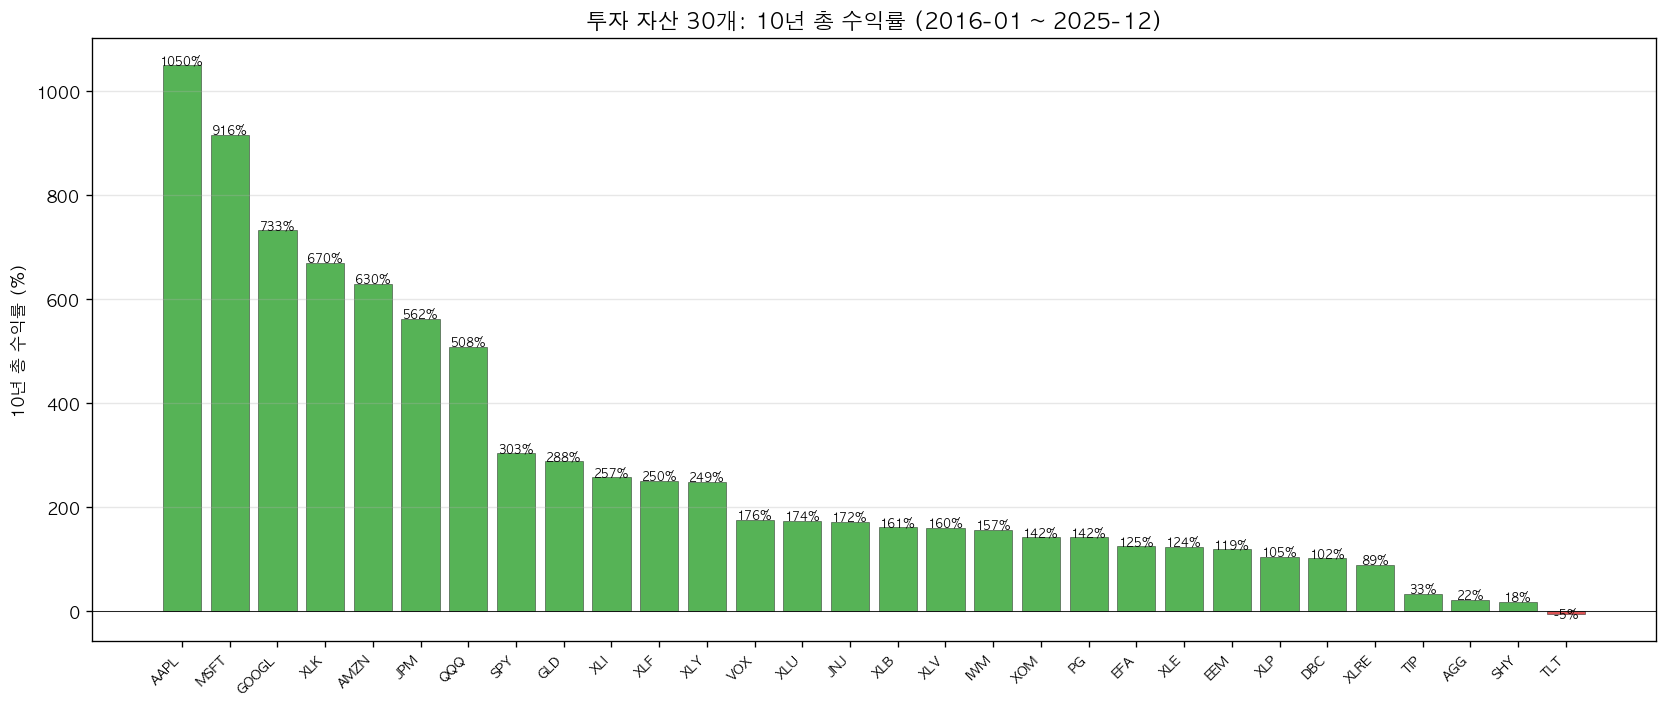

저장: images/step1_01_total_returns.png


In [30]:
# ============================================================
# 투자 자산 기초 통계 (시작/종료 가격, 10년 수익률)
# ============================================================

plt.rcParams['figure.dpi'] = 120

# 10년 총 수익률
total_ret = (df_portfolio.iloc[-1] / df_portfolio.iloc[0] - 1) * 100
total_ret = total_ret.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in total_ret]
bars = ax.bar(range(len(total_ret)), total_ret, color=colors, alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_xticks(range(len(total_ret)))
ax.set_xticklabels(total_ret.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('10년 총 수익률 (%)')
ax.set_title('투자 자산 30개: 10년 총 수익률 (2016-01 ~ 2025-12)', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# 값 라벨
for bar, val in zip(bars, total_ret):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + (2 if y >= 0 else -8),
            f'{val:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_01_total_returns.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_01_total_returns.png')

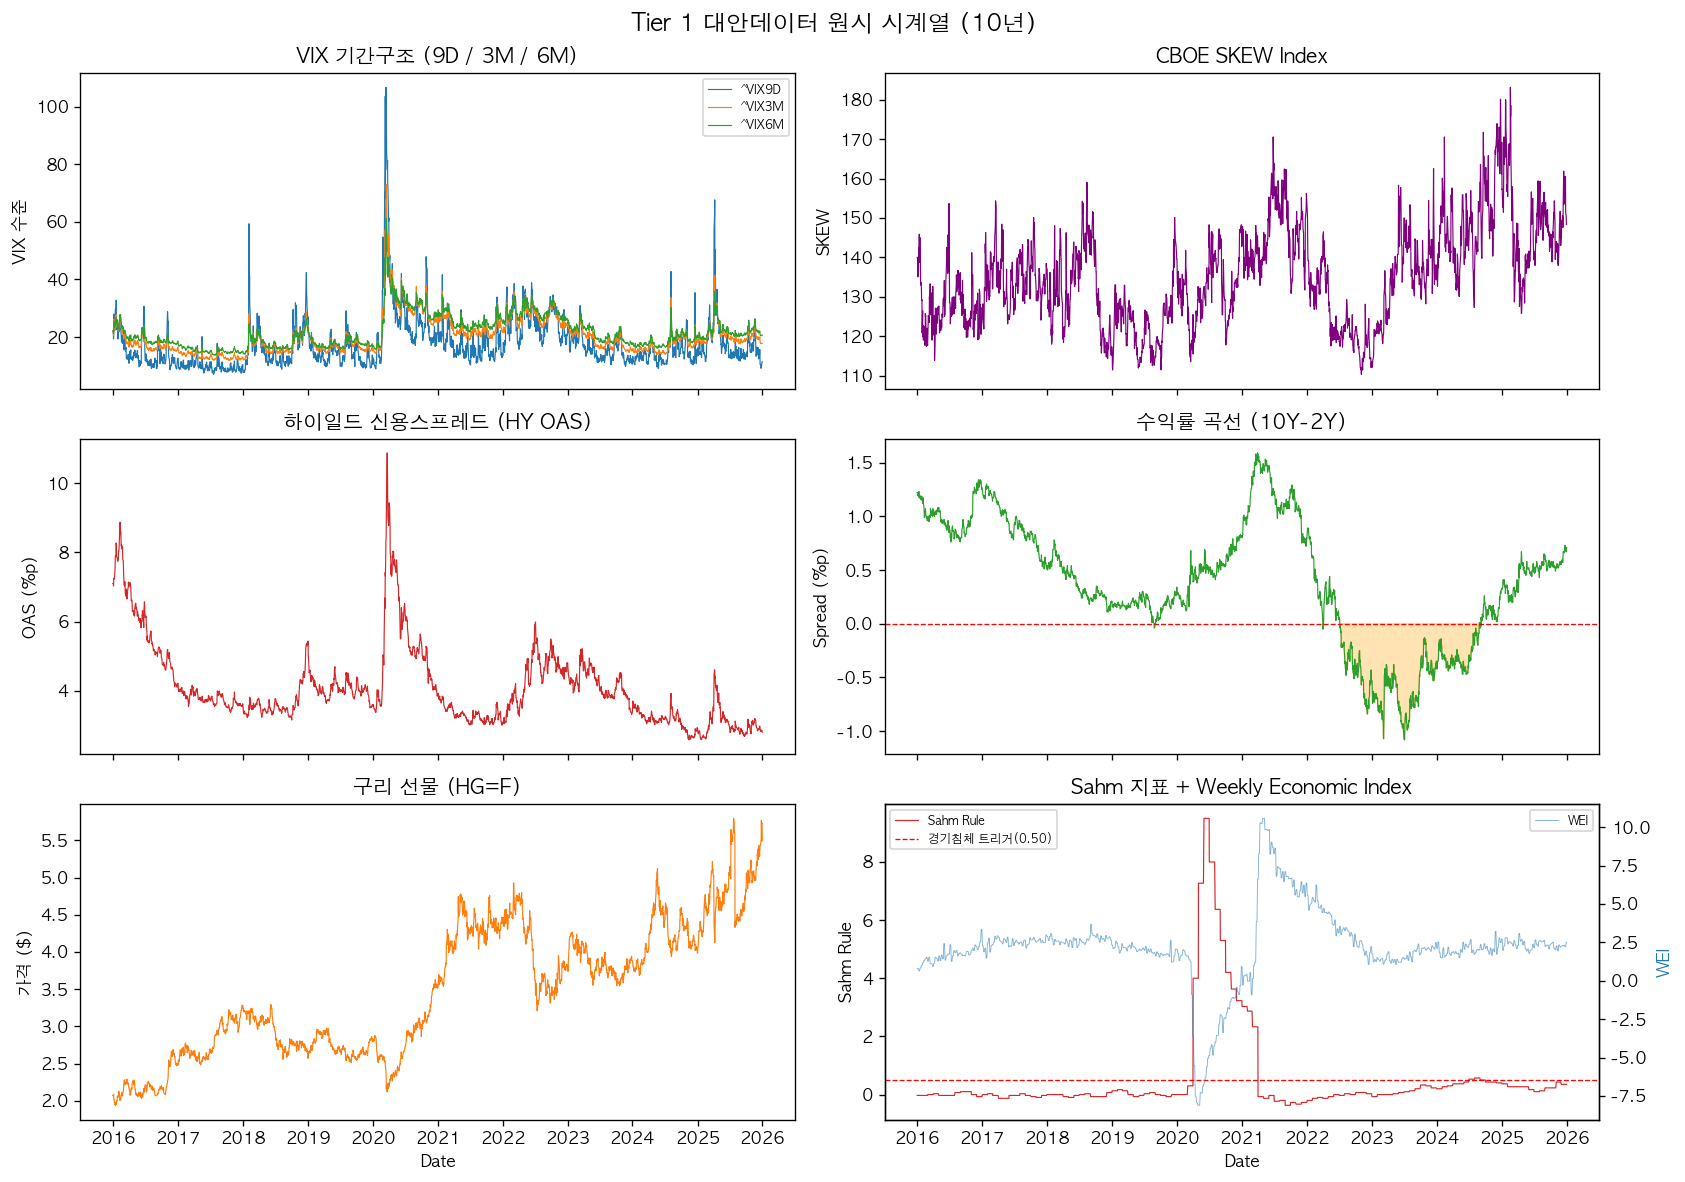

저장: images/step1_02_alt_data_preview.png


In [31]:
# ============================================================
# 대안데이터 시계열 미리보기
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('Tier 1 대안데이터 원시 시계열 (10년)', fontsize=14, fontweight='bold')

# VIX 기간구조
ax = axes[0, 0]
for t in ['^VIX9D', '^VIX3M', '^VIX6M']:
    if t in df_ext_alt.columns:
        ax.plot(df_ext_alt.index, df_ext_alt[t], linewidth=0.7, label=t)
ax.set_title('VIX 기간구조 (9D / 3M / 6M)')
ax.legend(fontsize=7)
ax.set_ylabel('VIX 수준')

# SKEW
ax = axes[0, 1]
if '^SKEW' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['^SKEW'], linewidth=0.7, color='purple')
ax.set_title('CBOE SKEW Index')
ax.set_ylabel('SKEW')

# HY 스프레드
ax = axes[1, 0]
ax.plot(df_fred.index, df_fred['BAMLH0A0HYM2'], linewidth=0.7, color='#d62728')
ax.set_title('하이일드 신용스프레드 (HY OAS)')
ax.set_ylabel('OAS (%p)')

# 수익률 곡선
ax = axes[1, 1]
ax.plot(df_fred.index, df_fred['T10Y2Y'], linewidth=0.7, color='#2ca02c')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.fill_between(df_fred.index, df_fred['T10Y2Y'], 0,
                where=df_fred['T10Y2Y'] < 0, color='orange', alpha=0.3)
ax.set_title('수익률 곡선 (10Y-2Y)')
ax.set_ylabel('Spread (%p)')

# 구리 선물
ax = axes[2, 0]
if 'HG=F' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['HG=F'], linewidth=0.7, color='#ff7f0e')
ax.set_title('구리 선물 (HG=F)')
ax.set_ylabel('가격 ($)')
ax.set_xlabel('Date')

# Sahm + WEI
ax = axes[2, 1]
ax.plot(df_fred.index, df_fred['SAHMREALTIME'], linewidth=0.7, color='#d62728', label='Sahm Rule')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='경기침체 트리거(0.50)')
ax2 = ax.twinx()
ax2.plot(df_fred.index, df_fred['WEI'], linewidth=0.5, color='#1f77b4', alpha=0.6, label='WEI')
ax2.set_ylabel('WEI', color='#1f77b4')
ax.set_title('Sahm 지표 + Weekly Economic Index')
ax.set_ylabel('Sahm Rule')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=7)
ax2.legend(loc='upper right', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_02_alt_data_preview.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_02_alt_data_preview.png')

---
## 1-5. CSV 저장

이후 Step에서 사용할 CSV 파일을 저장합니다.

| 파일 | 내용 | 사용처 |
|------|------|--------|
| portfolio_prices.csv | 투자 자산 30개 일별 종가 | Step2~7 전체 |
| external_prices.csv | 외부 지표 + 대안 yfinance 12개 | Step2 피처 엔지니어링 |
| fred_data.csv | FRED 8개 시리즈 | Step2 피처 엔지니어링 |

In [32]:
# ============================================================
# CSV 저장
# ============================================================

saves = {
    'portfolio_prices.csv': df_portfolio,
    'external_prices.csv': df_ext_alt,
    'fred_data.csv': df_fred,
}

print('=== CSV 저장 ===')
for fname, df in saves.items():
    path = os.path.join(DATA_DIR, fname)
    df.to_csv(path)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:30s} | {df.shape[0]:,}행 × {df.shape[1]:,}열 | {size_kb:.0f} KB')

print(f'\n저장 경로: {DATA_DIR}')
print('Step1 완료.')

=== CSV 저장 ===
  portfolio_prices.csv           | 2,609행 × 30열 | 1421 KB
  external_prices.csv            | 2,609행 × 12열 | 568 KB
  fred_data.csv                  | 2,609행 × 8열 | 145 KB

저장 경로: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/data
Step1 완료.
